# 🏦 Project 3 — Loan Eligibility Prediction
**Target Variable:** Loan_Status (Y = Approved / N = Rejected)  
**Algorithms:** Logistic Regression · Decision Tree · Random Forest · Gradient Boosting · SVM  
**Libraries:** Pandas · NumPy · Scikit-learn · Matplotlib · Seaborn

---
| Step | Description |
|---|---|
| 1 | Dataset construction — 614 loan applications, 12 features |
| 2 | EDA — distributions, missing values, class balance |
| 3 | Preprocessing — imputation, label encoding, feature engineering |
| 4 | Normalization — StandardScaler + stratified 80/20 split |
| 5 | Model training — 5 algorithms |
| 6 | Evaluation — Accuracy, F1, AUC, Precision, Recall, 5-Fold CV |
| 7 | **Dashboard 1** — EDA (16 inline charts) |
| 8 | **Dashboard 2** — Multi-Model Comparison (16 inline charts) |
| 9 | **Dashboard 3** — Best Model Deep Dive (8 inline charts) |


## Cell 1 — Imports

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, confusion_matrix, roc_auc_score, roc_curve,
    f1_score, precision_score, recall_score, classification_report,
    precision_recall_curve
)
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
print("All libraries loaded successfully")

All libraries loaded successfully


## Cell 2 — Global Style (run once before any visualization)

In [3]:
# ── Dark cyberpunk palette ───────────────────────────────────────────────────
BG     = '#060b12'   # page background
CARD   = '#0c1420'   # chart background
BORDER = '#162030'   # axes / grid
CYAN   = '#00d4ff'   # model 1
GOLD   = '#ffc136'   # model 2
GREEN  = '#00e676'   # approved / positive
ROSE   = '#ff3d6b'   # rejected / negative
PURPLE = '#b06bff'   # model 4
ORANGE = '#ff7b29'   # model 5
TEAL   = '#00bfa5'   # feature colour
SLATE  = '#3a5068'   # neutral / dim
WHITE  = '#ddeeff'   # labels / text

MODEL_COLORS = [CYAN, GOLD, GREEN, PURPLE, ORANGE]

plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'figure.facecolor'  : BG,
    'axes.facecolor'    : CARD,
    'axes.edgecolor'    : BORDER,
    'axes.labelcolor'   : '#7ab0cc',
    'axes.titlecolor'   : WHITE,
    'xtick.color'       : '#3a5068',
    'ytick.color'       : '#3a5068',
    'text.color'        : '#7ab0cc',
    'grid.color'        : BORDER,
    'grid.linewidth'    : 0.6,
    'legend.facecolor'  : CARD,
    'legend.edgecolor'  : BORDER,
    'legend.labelcolor' : '#7ab0cc',
})
print("Style configured")

Style configured


## Cell 3 — Dataset Construction
Synthetic dataset matching real Loan Prediction dataset semantics (same as Dream Housing Finance Company dataset on Kaggle).

In [4]:
np.random.seed(42)
n = 614

# ── Applicant demographics ────────────────────────────────────────────────────
gender        = np.random.choice(['Male','Female'],  n, p=[0.81, 0.19])
married       = np.random.choice(['Yes','No'],       n, p=[0.65, 0.35])
dependents    = np.random.choice(['0','1','2','3+'], n, p=[0.57, 0.17, 0.16, 0.10])
education     = np.random.choice(['Graduate','Not Graduate'], n, p=[0.78, 0.22])
self_employed = np.random.choice(['Yes','No'],       n, p=[0.14, 0.86])
credit_hist   = np.random.choice([1.0, 0.0],        n, p=[0.84, 0.16])
prop_area     = np.random.choice(['Urban','Semiurban','Rural'], n, p=[0.38, 0.37, 0.25])

# ── Financial features ────────────────────────────────────────────────────────
app_income = np.where(education == 'Graduate',
    np.random.lognormal(8.3, 0.7, n).clip(1000, 81000),
    np.random.lognormal(7.8, 0.6, n).clip(1000, 40000)).astype(int)

coapp_income = np.where(married == 'Yes',
    np.random.choice([0]*40 + list(np.random.randint(1000, 35000, 60)), n),
    np.random.choice([0]*80 + list(np.random.randint(1000, 10000, 20)), n)).astype(float)

loan_amount = (0.003*app_income + 0.001*coapp_income +
    np.where(prop_area=='Urban', 50, np.where(prop_area=='Semiurban', 30, 20)) +
    np.random.normal(0, 30, n)).clip(9, 700).astype(int)

loan_term = np.random.choice([60,84,120,180,240,300,360,480], n,
    p=[0.01,0.01,0.03,0.04,0.03,0.03,0.83,0.02])

# ── Target: rule-based approval with noise ────────────────────────────────────
def approve(i):
    s = 0
    if credit_hist[i] == 1: s += 40
    if education[i] == 'Graduate': s += 10
    if married[i] == 'Yes': s += 8
    if prop_area[i] == 'Semiurban': s += 12
    elif prop_area[i] == 'Urban': s += 8
    ti = app_income[i] + coapp_income[i]
    emi = loan_amount[i] * 1000 / loan_term[i]
    dti = emi / max(ti, 1)
    if dti < 0.2: s += 20
    elif dti < 0.4: s += 10
    if ti > 8000: s += 10
    s += np.random.normal(0, 10)
    return 1 if s >= 55 else 0

loan_status = np.array(['Y' if approve(i) else 'N' for i in range(n)])

df = pd.DataFrame({
    'Loan_ID'          : [f'LP{str(i).zfill(6)}' for i in range(n)],
    'Gender'           : gender,        'Married'    : married,
    'Dependents'       : dependents,    'Education'  : education,
    'Self_Employed'    : self_employed, 'ApplicantIncome'   : app_income,
    'CoapplicantIncome': coapp_income,  'LoanAmount'        : loan_amount,
    'Loan_Amount_Term' : loan_term,     'Credit_History'    : credit_hist,
    'Property_Area'    : prop_area,     'Loan_Status'       : loan_status
})

# Inject realistic missing values
for col, rate in {'Gender':0.013,'Married':0.003,'Dependents':0.025,'Self_Employed':0.032,
                  'LoanAmount':0.036,'Loan_Amount_Term':0.021,'Credit_History':0.083}.items():
    df.loc[np.random.random(n) < rate, col] = np.nan

print(f"Shape      : {df.shape}")
print(f"Approved   : {(df.Loan_Status=='Y').sum()}  ({(df.Loan_Status=='Y').mean()*100:.1f}%)")
print(f"Rejected   : {(df.Loan_Status=='N').sum()}  ({(df.Loan_Status=='N').mean()*100:.1f}%)")
print(f"Missing    : {df.isnull().sum().sum()} cells across {df.isnull().any().sum()} columns")
df.head()

Shape      : (614, 13)
Approved   : 545  (88.8%)
Rejected   : 69  (11.2%)
Missing    : 126 cells across 7 columns


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP000000,Male,No,3+,Graduate,No,16006,0.0,44.0,360.0,1.0,Semiurban,Y
1,LP000001,Female,No,0,Graduate,No,1525,0.0,29.0,360.0,1.0,Semiurban,Y
2,LP000002,Male,Yes,2,Not Graduate,No,2473,7213.0,56.0,360.0,1.0,Rural,Y
3,LP000003,Male,Yes,0,Graduate,NaN,11411,0.0,84.0,360.0,1.0,Semiurban,Y
4,LP000004,Male,No,0,Graduate,No,19732,9073.0,147.0,360.0,1.0,Urban,Y


## Cell 4 — Exploratory Data Analysis

In [5]:
print("=== Missing Values ===")
miss = df.isnull().sum(); pct = (miss/len(df)*100).round(2)
print(pd.DataFrame({'Count':miss,'Pct (%)':pct})[miss>0].sort_values('Pct (%)',ascending=False))

print("\n=== Approval rate by Credit History ===")
print(df.groupby('Credit_History')['Loan_Status'].apply(lambda x:(x=='Y').mean()).round(3))

print("\n=== Approval rate by Property Area ===")
print(df.groupby('Property_Area')['Loan_Status'].apply(lambda x:(x=='Y').mean()).round(3))

print("\n=== Numerical Statistics ===")
df[['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term']].describe().round(2)

=== Missing Values ===
                  Count  Pct (%)
Credit_History       40     6.51
Dependents           22     3.58
Self_Employed        21     3.42
LoanAmount           16     2.61
Loan_Amount_Term     16     2.61
Gender                8     1.30
Married               3     0.49

=== Approval rate by Credit History ===
Credit_History
0.0    0.300
1.0    0.982
Name: Loan_Status, dtype: float64

=== Approval rate by Property Area ===
Property_Area
Rural        0.829
Semiurban    0.924
Urban        0.886
Name: Loan_Status, dtype: float64

=== Numerical Statistics ===


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term
count,614.00,614.00,598.00,598.00
mean,4602.49,5588.01,56.89,338.09
std,4043.26,8578.21,34.47,68.74
min,1000.00,0.00,9.00,60.00
25%,2154.00,0.00,30.25,360.00
50%,3442.50,0.00,54.50,360.00
75%,5549.00,9417.00,78.75,360.00
max,38955.00,31988.00,202.00,480.00


## Cell 5 — Data Preprocessing & Feature Engineering

In [6]:
df_p = df.drop('Loan_ID', axis=1).copy()

# ── Step 1: Impute missing values ─────────────────────────────────────────────
for col in ['Gender','Married','Dependents','Self_Employed']:
    df_p[col] = df_p[col].fillna(df_p[col].mode()[0])
for col in ['LoanAmount','Loan_Amount_Term','Credit_History']:
    df_p[col] = df_p[col].fillna(df_p[col].median())
print(f"Missing after imputation: {df_p.isnull().sum().sum()}  checkmark")

# ── Step 2: Feature Engineering ──────────────────────────────────────────────
df_p['TotalIncome']    = df_p['ApplicantIncome'] + df_p['CoapplicantIncome']
df_p['Log_Income']     = np.log1p(df_p['TotalIncome'])      # de-skew income
df_p['Log_Loan']       = np.log1p(df_p['LoanAmount'])       # de-skew loan amount
df_p['EMI']            = df_p['LoanAmount'] / df_p['Loan_Amount_Term']
df_p['Balance_Income'] = df_p['Log_Income'] - df_p['EMI']   # income after EMI
df_p['DebtToIncome']   = (df_p['EMI'] * 1000) / df_p['TotalIncome'].clip(1)

print("\nEngineered features: TotalIncome, Log_Income, Log_Loan, EMI, Balance_Income, DebtToIncome")

# ── Step 3: Label Encoding ────────────────────────────────────────────────────
le = LabelEncoder()
for col in ['Gender','Married','Dependents','Education','Self_Employed','Property_Area','Loan_Status']:
    df_p[col] = le.fit_transform(df_p[col].astype(str))

print("Encoding complete")
df_p.head()

Missing after imputation: 0  checkmark

Engineered features: TotalIncome, Log_Income, Log_Loan, EMI, Balance_Income, DebtToIncome
Encoding complete


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,Log_Income,Log_Loan,EMI,Balance_Income,DebtToIncome
0,1,0,3,0,0,16006,0.0,44.0,360.0,1.0,1,1,16006.0,9.680781,3.806662,0.122222,9.558559,0.007636
1,0,0,0,0,0,1525,0.0,29.0,360.0,1.0,1,1,1525.0,7.330405,3.401197,0.080556,7.249850,0.052823
2,1,1,2,1,0,2473,7213.0,56.0,360.0,1.0,0,1,9686.0,9.178540,4.043051,0.155556,9.022985,0.016060
3,1,1,0,0,0,11411,0.0,84.0,360.0,1.0,1,1,11411.0,9.342421,4.442651,0.233333,9.109087,0.020448
4,1,0,0,0,0,19732,9073.0,147.0,360.0,1.0,2,1,28805.0,10.268339,4.997212,0.408333,9.860006,0.014176


## Cell 6 — Normalization & Stratified Train/Test Split

In [7]:
feat_cols = [
    'Gender','Married','Dependents','Education','Self_Employed',
    'Log_Income','Log_Loan','Loan_Amount_Term','Credit_History',
    'Property_Area','EMI','Balance_Income','DebtToIncome'
]

X = df_p[feat_cols].values
y = df_p['Loan_Status'].values

# StandardScaler
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Stratified 80/20 split (preserves class proportions)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train : {X_train.shape[0]} samples  |  Approval: {y_train.mean()*100:.1f}%")
print(f"Test  : {X_test.shape[0]} samples   |  Approval: {y_test.mean()*100:.1f}%")
print(f"Features: {len(feat_cols)}")

Train : 491 samples  |  Approval: 88.8%
Test  : 123 samples   |  Approval: 88.6%
Features: 13


## Cell 7 — Train 5 ML Models & Evaluate

In [8]:
models = {
    'Logistic\nRegression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision\nTree'       : DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random\nForest'       : RandomForestClassifier(n_estimators=150, max_depth=8, random_state=42),
    'Gradient\nBoosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM'                   : SVC(kernel='rbf', probability=True, random_state=42),
}

results = {}
skf     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"{'Model':22s} {'Acc':>7} {'F1':>7} {'AUC':>7} {'Prec':>7} {'Rec':>7} {'CV-5':>7}")
print("-"*62)

for name, clf in models.items():
    clf.fit(X_train, y_train)
    yp    = clf.predict(X_test)
    yprob = clf.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, yprob)
    cv5   = cross_val_score(clf, X_scaled, y, cv=skf, scoring='accuracy').mean()
    results[name] = {
        'clf':clf, 'yp':yp, 'yprob':yprob,
        'acc' : accuracy_score(y_test, yp),
        'f1'  : f1_score(y_test, yp),
        'auc' : roc_auc_score(y_test, yprob),
        'prec': precision_score(y_test, yp),
        'rec' : recall_score(y_test, yp),
        'cv5' : cv5,
        'cm'  : confusion_matrix(y_test, yp),
        'fpr' : fpr, 'tpr' : tpr
    }
    short = name.replace('\n', ' ')
    r = results[name]
    print(f"  {short:20s} {r['acc']:7.4f} {r['f1']:7.4f} {r['auc']:7.4f} {r['prec']:7.4f} {r['rec']:7.4f} {r['cv5']:7.4f}")

# Best model by AUC
best_auc = max(results, key=lambda k: results[k]['auc'])
best_res = results[best_auc]
best_clf = models[best_auc]
print(f"\nBest model (AUC): {best_auc.replace(chr(10),' ')}")

# Random Forest feature importance
rf       = models['Random\nForest']
feat_imp = pd.Series(rf.feature_importances_, index=feat_cols).sort_values(ascending=False)
print("\nFeature Importances (RF):")
print(feat_imp.round(4).to_string())

Model                      Acc      F1     AUC    Prec     Rec    CV-5
--------------------------------------------------------------
  Logistic Regression   0.9837  0.9908  0.9974  0.9908  0.9908  0.9381
  Decision Tree         0.9187  0.9528  0.8958  0.9806  0.9266  0.9170
  Random Forest         0.9593  0.9770  0.9895  0.9815  0.9725  0.9349
  Gradient Boosting     0.9756  0.9862  0.9882  0.9907  0.9817  0.9463
  SVM                   0.9756  0.9863  0.9928  0.9818  0.9908  0.9398

Best model (AUC): Logistic Regression

Feature Importances (RF):
Credit_History      0.3847
Balance_Income      0.1109
DebtToIncome        0.1043
Log_Income          0.0890
EMI                 0.0782
Log_Loan            0.0741
Property_Area       0.0414
Education           0.0343
Dependents          0.0252
Married             0.0217
Loan_Amount_Term    0.0153
Gender              0.0120
Self_Employed       0.0090


## Cell 8 — Dashboard 1: EDA (16 charts)
> Run after Cells 1–7. All charts render inline.

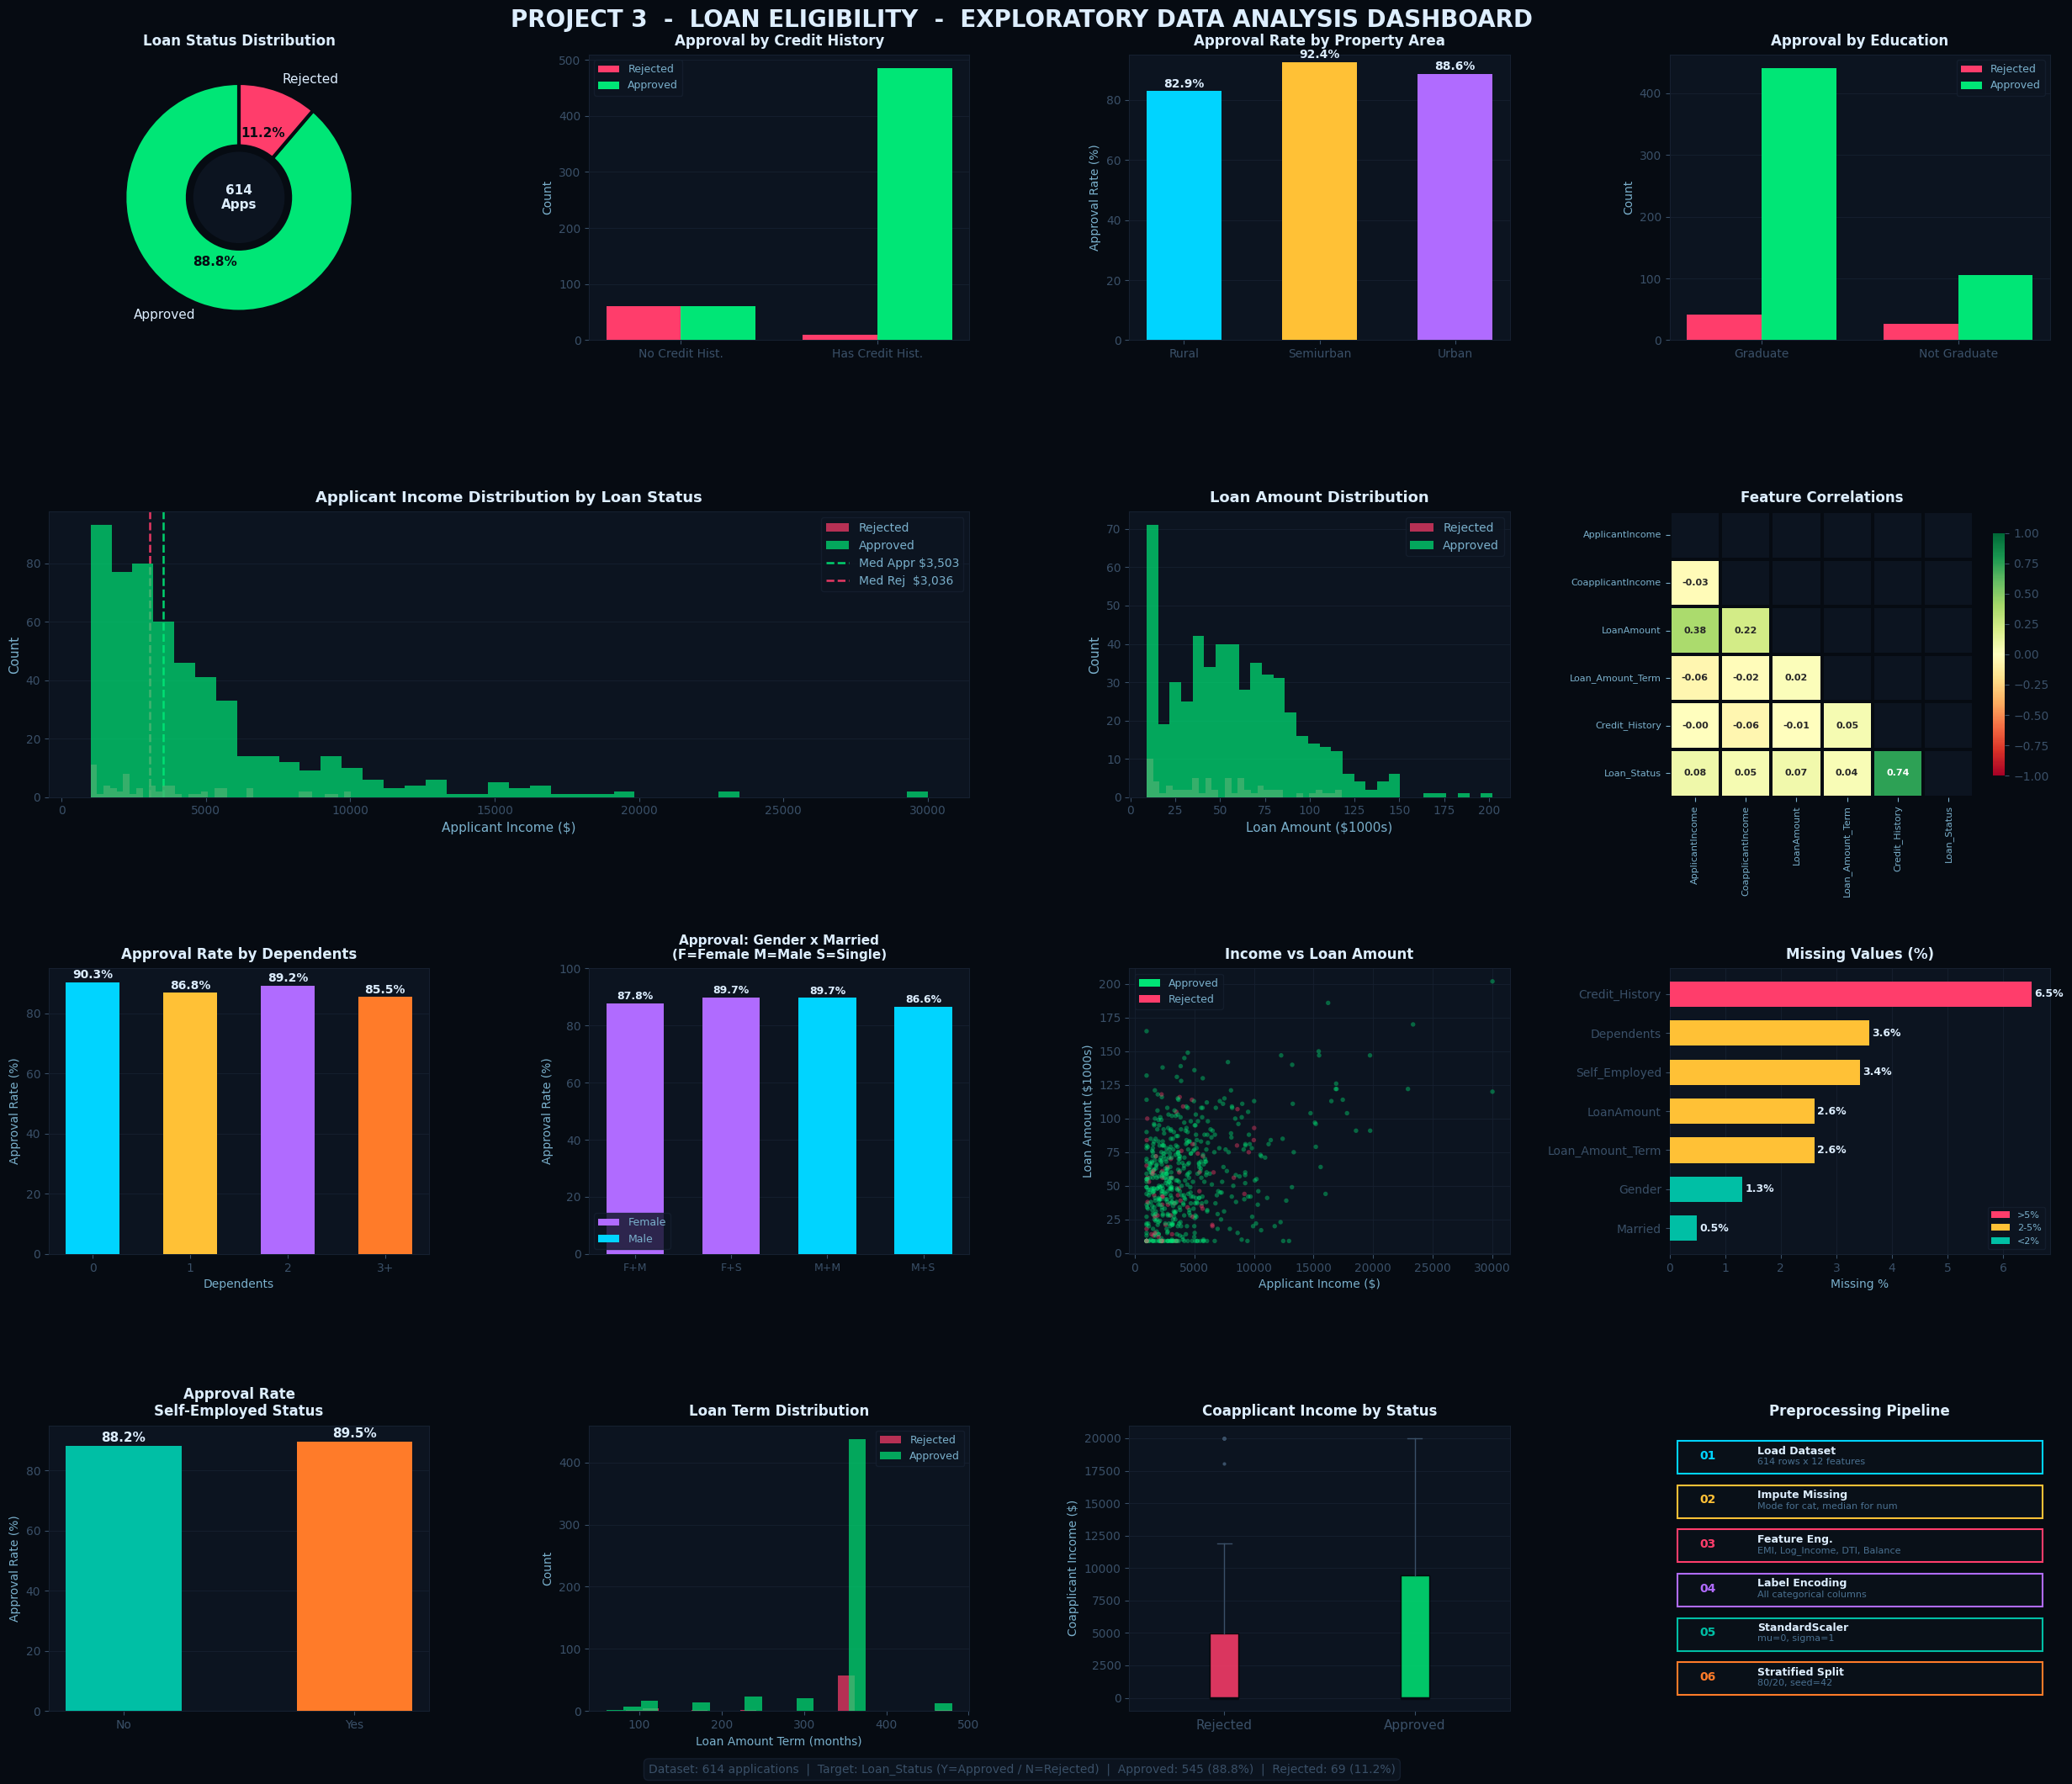

In [10]:
mnames = list(results.keys())

fig = plt.figure(figsize=(26, 22), facecolor=BG)
fig.suptitle('PROJECT 3  -  LOAN ELIGIBILITY  -  EXPLORATORY DATA ANALYSIS DASHBOARD',
             fontsize=20, fontweight='bold', color=WHITE, y=0.975)
gs = gridspec.GridSpec(4, 4, figure=fig, hspace=0.60, wspace=0.42,
                       top=0.950, bottom=0.055, left=0.055, right=0.970)

# ── Row 0 ─────────────────────────────────────────────────────────────────────

# [0,0] Loan Status donut
ax = fig.add_subplot(gs[0, 0])
ls_c = df['Loan_Status'].value_counts()
wedges, texts, ats = ax.pie(ls_c.values, labels=['Approved','Rejected'],
    autopct='%1.1f%%', colors=[GREEN, ROSE], startangle=90,
    wedgeprops=dict(edgecolor=BG, linewidth=3, width=0.55))
for t in texts: t.set_color(WHITE); t.set_fontsize(11)
for at in ats:  at.set_color(BG); at.set_fontweight('bold'); at.set_fontsize(11)
ax.add_patch(plt.Circle((0,0), 0.40, fc=CARD))
ax.text(0, 0, f'{n}\nApps', ha='center', va='center', fontsize=11, fontweight='bold', color=WHITE)
ax.set_title('Loan Status Distribution', fontsize=12, fontweight='bold', pad=8)

# [0,1] Approval by Credit History
ax = fig.add_subplot(gs[0, 1])
df_t = df.copy(); df_t['Credit_History'] = df_t['Credit_History'].fillna(0)
ch   = df_t.groupby(['Credit_History','Loan_Status']).size().unstack(fill_value=0)
x = np.arange(len(ch)); w = 0.38
ax.bar(x-w/2, ch.get('N',0).values, w, color=ROSE,  label='Rejected', edgecolor='none', zorder=3)
ax.bar(x+w/2, ch.get('Y',0).values, w, color=GREEN, label='Approved', edgecolor='none', zorder=3)
ax.set_xticks(x); ax.set_xticklabels(['No Credit Hist.','Has Credit Hist.'], fontsize=10)
ax.set_title('Approval by Credit History', fontsize=12, fontweight='bold', pad=8)
ax.set_ylabel('Count', fontsize=10); ax.legend(fontsize=9)
ax.yaxis.grid(True, zorder=0); ax.set_axisbelow(True)

# [0,2] Approval rate by Property Area
ax = fig.add_subplot(gs[0, 2])
pa_rate = df.groupby('Property_Area')['Loan_Status'].apply(lambda x:(x=='Y').mean()*100)
bars = ax.bar(pa_rate.index, pa_rate.values, color=[CYAN,GOLD,PURPLE], edgecolor='none', zorder=3, width=0.55)
for bar, val in zip(bars, pa_rate.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold', color=WHITE)
ax.set_title('Approval Rate by Property Area', fontsize=12, fontweight='bold', pad=8)
ax.set_ylabel('Approval Rate (%)', fontsize=10); ax.set_ylim(0, 95)
ax.yaxis.grid(True, zorder=0); ax.set_axisbelow(True)

# [0,3] Approval by Education
ax = fig.add_subplot(gs[0, 3])
ed = df.groupby(['Education','Loan_Status']).size().unstack(fill_value=0)
x2 = np.arange(len(ed))
ax.bar(x2-w/2, ed.get('N',0).values, w, color=ROSE,  label='Rejected', edgecolor='none', zorder=3)
ax.bar(x2+w/2, ed.get('Y',0).values, w, color=GREEN, label='Approved', edgecolor='none', zorder=3)
ax.set_xticks(x2); ax.set_xticklabels(['Graduate','Not Graduate'], fontsize=10)
ax.set_title('Approval by Education', fontsize=12, fontweight='bold', pad=8)
ax.set_ylabel('Count', fontsize=10); ax.legend(fontsize=9)
ax.yaxis.grid(True, zorder=0); ax.set_axisbelow(True)

# ── Row 1 ─────────────────────────────────────────────────────────────────────

# [1,0:2] Applicant Income histogram — wide
ax = fig.add_subplot(gs[1, 0:2])
inc_y = df[df['Loan_Status']=='Y']['ApplicantIncome'].clip(0, 30000)
inc_n = df[df['Loan_Status']=='N']['ApplicantIncome'].clip(0, 30000)
ax.hist(inc_n, bins=40, alpha=0.70, color=ROSE,  label='Rejected', edgecolor='none', zorder=3)
ax.hist(inc_y, bins=40, alpha=0.70, color=GREEN, label='Approved', edgecolor='none', zorder=3)
ax.axvline(inc_y.median(), color=GREEN, lw=1.8, ls='--', alpha=0.9, label=f'Med Appr ${inc_y.median():,.0f}')
ax.axvline(inc_n.median(), color=ROSE,  lw=1.8, ls='--', alpha=0.9, label=f'Med Rej  ${inc_n.median():,.0f}')
ax.set_title('Applicant Income Distribution by Loan Status', fontsize=13, fontweight='bold', pad=8)
ax.set_xlabel('Applicant Income ($)', fontsize=11); ax.set_ylabel('Count', fontsize=11)
ax.legend(fontsize=10); ax.yaxis.grid(True, zorder=0); ax.set_axisbelow(True)

# [1,2] Loan Amount distribution
ax = fig.add_subplot(gs[1, 2])
ax.hist(df[df['Loan_Status']=='N']['LoanAmount'].dropna(), bins=30, alpha=0.70,
        color=ROSE, label='Rejected', edgecolor='none', zorder=3)
ax.hist(df[df['Loan_Status']=='Y']['LoanAmount'].dropna(), bins=30, alpha=0.70,
        color=GREEN, label='Approved', edgecolor='none', zorder=3)
ax.set_title('Loan Amount Distribution', fontsize=13, fontweight='bold', pad=8)
ax.set_xlabel('Loan Amount ($1000s)', fontsize=11); ax.set_ylabel('Count', fontsize=11)
ax.legend(fontsize=10); ax.yaxis.grid(True, zorder=0); ax.set_axisbelow(True)

# [1,3] Correlation heatmap
ax = fig.add_subplot(gs[1, 3])
num_cols_h = ['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term','Credit_History']
df_corr    = df[num_cols_h].copy()
df_corr['Loan_Status'] = (df['Loan_Status']=='Y').astype(int)
corr = df_corr.dropna().corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=1.5, linecolor=BG, annot_kws={'size':8,'weight':'bold'},
            ax=ax, cbar_kws={'shrink':0.85}, vmin=-1, vmax=1)
ax.set_title('Feature Correlations', fontsize=12, fontweight='bold', pad=8, color=WHITE)
ax.tick_params(colors='#7ab0cc', labelsize=8); ax.set_facecolor(CARD)

# ── Row 2 ─────────────────────────────────────────────────────────────────────

# [2,0] Approval rate by Dependents
ax = fig.add_subplot(gs[2, 0])
dep_rate = df.groupby('Dependents')['Loan_Status'].apply(lambda x:(x=='Y').mean()*100)
bars_d   = ax.bar(dep_rate.index, dep_rate.values,
                  color=[CYAN,GOLD,PURPLE,ORANGE][:len(dep_rate)], edgecolor='none', zorder=3, width=0.55)
for bar, val in zip(bars_d, dep_rate.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold', color=WHITE)
ax.set_title('Approval Rate by Dependents', fontsize=12, fontweight='bold', pad=8)
ax.set_xlabel('Dependents', fontsize=10); ax.set_ylabel('Approval Rate (%)', fontsize=10)
ax.set_ylim(0, 95); ax.yaxis.grid(True, zorder=0); ax.set_axisbelow(True)

# [2,1] Gender x Married approval rate
ax = fig.add_subplot(gs[2, 1])
df_gm     = df.dropna(subset=['Gender'])
rate_vals = []; labels3 = []
for g in ['Female','Male']:
    for m in ['Yes','No']:
        sub = df_gm[(df_gm['Gender']==g) & (df_gm['Married']==m)]
        if len(sub) > 0:
            rate_vals.append((sub['Loan_Status']=='Y').mean()*100)
            labels3.append(f"{g[0]}+{'M' if m=='Yes' else 'S'}")
x3 = np.arange(len(labels3))
bars3 = ax.bar(x3, rate_vals, color=[PURPLE,PURPLE,CYAN,CYAN][:len(labels3)],
               edgecolor='none', zorder=3, width=0.6)
for bar, val in zip(bars3, rate_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold', color=WHITE)
ax.set_xticks(x3); ax.set_xticklabels(labels3, fontsize=9)
ax.set_title('Approval: Gender x Married\n(F=Female M=Male S=Single)', fontsize=11, fontweight='bold', pad=8)
ax.set_ylabel('Approval Rate (%)', fontsize=10); ax.set_ylim(0, 100)
ax.legend(handles=[Patch(facecolor=PURPLE,label='Female'),Patch(facecolor=CYAN,label='Male')], fontsize=9)
ax.yaxis.grid(True, zorder=0); ax.set_axisbelow(True)

# [2,2] Income vs Loan Amount scatter
ax = fig.add_subplot(gs[2, 2])
df_s  = df.dropna(subset=['LoanAmount'])
sc_c  = [GREEN if s=='Y' else ROSE for s in df_s['Loan_Status']]
ax.scatter(df_s['ApplicantIncome'].clip(0,30000), df_s['LoanAmount'],
           c=sc_c, alpha=0.40, s=15, edgecolors='none', zorder=3)
ax.set_title('Income vs Loan Amount', fontsize=12, fontweight='bold', pad=8)
ax.set_xlabel('Applicant Income ($)', fontsize=10); ax.set_ylabel('Loan Amount ($1000s)', fontsize=10)
ax.legend(handles=[Patch(facecolor=GREEN,label='Approved'),Patch(facecolor=ROSE,label='Rejected')], fontsize=9)
ax.yaxis.grid(True,zorder=0); ax.xaxis.grid(True,zorder=0); ax.set_axisbelow(True)

# [2,3] Missing values bar
ax = fig.add_subplot(gs[2, 3])
miss_m = (df.isnull().sum()/len(df)*100).sort_values(ascending=True)
miss_m = miss_m[miss_m > 0]
bc_m   = [ROSE if v>5 else GOLD if v>2 else TEAL for v in miss_m.values]
ax.barh(miss_m.index, miss_m.values, color=bc_m, edgecolor='none', zorder=3, height=0.65)
for i,(col,val) in enumerate(zip(miss_m.index,miss_m.values)):
    ax.text(val+0.05, i, f'{val:.1f}%', va='center', fontsize=9, fontweight='bold', color=WHITE)
ax.set_title('Missing Values (%)', fontsize=12, fontweight='bold', pad=8)
ax.set_xlabel('Missing %', fontsize=10)
ax.legend(handles=[Patch(facecolor=ROSE,label='>5%'),Patch(facecolor=GOLD,label='2-5%'),
                   Patch(facecolor=TEAL,label='<2%')], fontsize=8)
ax.xaxis.grid(True, zorder=0); ax.set_axisbelow(True)

# ── Row 3 ─────────────────────────────────────────────────────────────────────

# [3,0] Self-Employed approval
ax = fig.add_subplot(gs[3, 0])
se      = df.dropna(subset=['Self_Employed'])
se_rate = se.groupby('Self_Employed')['Loan_Status'].apply(lambda x:(x=='Y').mean()*100)
bars4   = ax.bar(se_rate.index, se_rate.values, color=[TEAL,ORANGE], edgecolor='none', zorder=3, width=0.5)
for bar, val in zip(bars4, se_rate.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold', color=WHITE)
ax.set_title('Approval Rate\nSelf-Employed Status', fontsize=12, fontweight='bold', pad=8)
ax.set_ylabel('Approval Rate (%)', fontsize=10); ax.set_ylim(0, 95)
ax.yaxis.grid(True, zorder=0); ax.set_axisbelow(True)

# [3,1] Loan term distribution
ax = fig.add_subplot(gs[3, 1])
df_lt = df.dropna(subset=['Loan_Amount_Term'])
ax.hist(df_lt[df_lt['Loan_Status']=='N']['Loan_Amount_Term'], bins=20,
        alpha=0.70, color=ROSE, label='Rejected', edgecolor='none', zorder=3)
ax.hist(df_lt[df_lt['Loan_Status']=='Y']['Loan_Amount_Term'], bins=20,
        alpha=0.70, color=GREEN, label='Approved', edgecolor='none', zorder=3)
ax.set_title('Loan Term Distribution', fontsize=12, fontweight='bold', pad=8)
ax.set_xlabel('Loan Amount Term (months)', fontsize=10); ax.set_ylabel('Count', fontsize=10)
ax.legend(fontsize=9); ax.yaxis.grid(True, zorder=0); ax.set_axisbelow(True)

# [3,2] Coapplicant Income boxplot by status
ax = fig.add_subplot(gs[3, 2])
coapp_y = df[df['Loan_Status']=='Y']['CoapplicantIncome'].clip(0, 20000)
coapp_n = df[df['Loan_Status']=='N']['CoapplicantIncome'].clip(0, 20000)
bp = ax.boxplot([coapp_n.values, coapp_y.values], patch_artist=True,
    medianprops=dict(color=BG, linewidth=2.5),
    whiskerprops=dict(color=SLATE), capprops=dict(color=SLATE),
    flierprops=dict(marker='o', markerfacecolor=SLATE, markersize=3, linestyle='none', markeredgewidth=0))
for patch, col in zip(bp['boxes'], [ROSE, GREEN]):
    patch.set_facecolor(col); patch.set_alpha(0.85)
ax.set_xticklabels(['Rejected','Approved'], fontsize=11)
ax.set_title('Coapplicant Income by Status', fontsize=12, fontweight='bold', pad=8)
ax.set_ylabel('Coapplicant Income ($)', fontsize=10)
ax.yaxis.grid(True, zorder=0); ax.set_axisbelow(True)

# [3,3] Preprocessing pipeline card
ax = fig.add_subplot(gs[3, 3]); ax.axis('off')
steps = [('01','Load Dataset',     '614 rows x 12 features',     CYAN),
         ('02','Impute Missing',   'Mode for cat, median for num',GOLD),
         ('03','Feature Eng.',     'EMI, Log_Income, DTI, Balance',ROSE),
         ('04','Label Encoding',   'All categorical columns',     PURPLE),
         ('05','StandardScaler',   'mu=0, sigma=1',               TEAL),
         ('06','Stratified Split', '80/20, seed=42',              ORANGE)]
for i, (num, title, detail, col) in enumerate(steps):
    yb = 0.93 - i*0.155
    ax.add_patch(plt.Rectangle((0.02, yb-0.10), 0.96, 0.115,
                                facecolor='#091018', edgecolor=col, linewidth=1.5,
                                transform=ax.transAxes, clip_on=False))
    ax.text(0.08, yb-0.037, num,    transform=ax.transAxes, fontsize=10, fontweight='bold', color=col, va='center')
    ax.text(0.23, yb-0.020, title,  transform=ax.transAxes, fontsize=9,  fontweight='bold', color=WHITE, va='center')
    ax.text(0.23, yb-0.058, detail, transform=ax.transAxes, fontsize=8,  color='#4a7090', va='center')
ax.set_title('Preprocessing Pipeline', fontsize=12, fontweight='bold', pad=8)

fig.text(0.50, 0.020,
    f'Dataset: {n} applications  |  Target: Loan_Status (Y=Approved / N=Rejected)  |  '
    f'Approved: {(df.Loan_Status=="Y").sum()} ({(df.Loan_Status=="Y").mean()*100:.1f}%)  |  '
    f'Rejected: {(df.Loan_Status=="N").sum()} ({(df.Loan_Status=="N").mean()*100:.1f}%)',
    ha='center', va='bottom', fontsize=10, color=SLATE,
    bbox=dict(boxstyle='round,pad=0.4', facecolor=CARD, edgecolor=BORDER, alpha=0.9))

plt.tight_layout(rect=[0, 0.025, 1, 0.97])
plt.show()

## Cell 9 — Dashboard 2: Multi-Model Comparison (16 charts)
> Run after Cells 1–7.

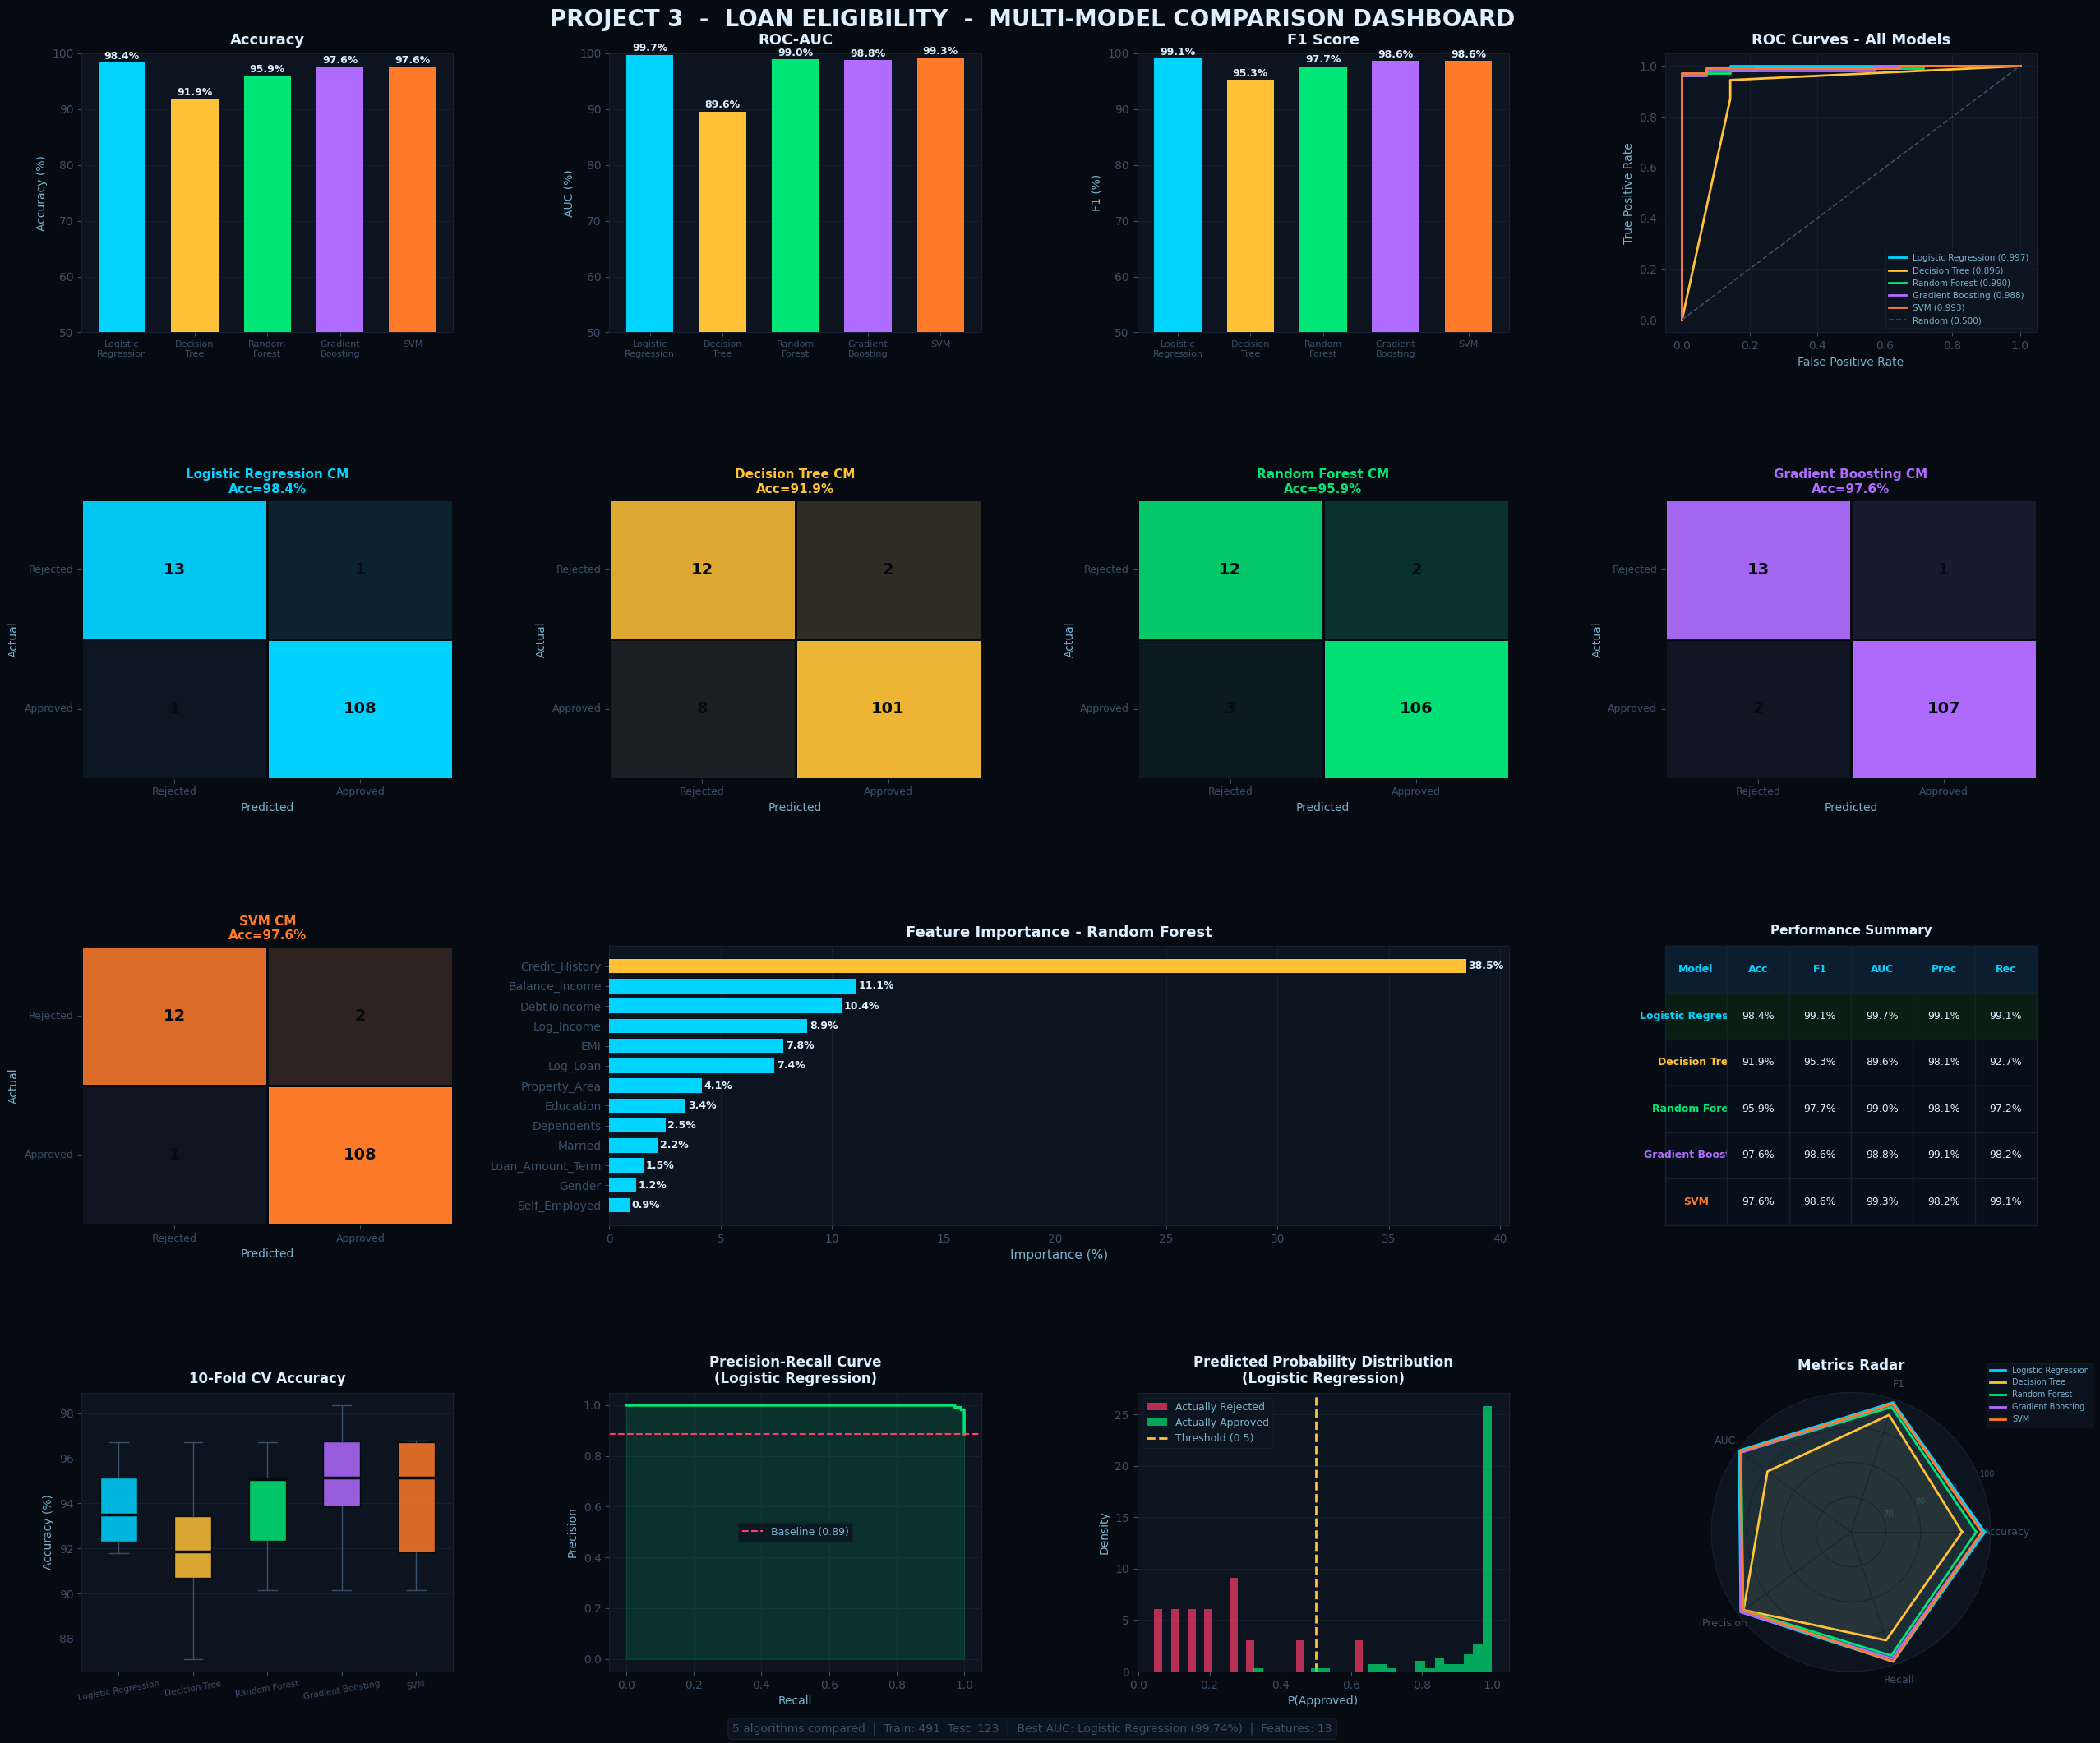

In [11]:
fig2 = plt.figure(figsize=(26, 22), facecolor=BG)
fig2.suptitle('PROJECT 3  -  LOAN ELIGIBILITY  -  MULTI-MODEL COMPARISON DASHBOARD',
              fontsize=20, fontweight='bold', color=WHITE, y=0.975)
gs2 = gridspec.GridSpec(4, 4, figure=fig2, hspace=0.60, wspace=0.42,
                        top=0.950, bottom=0.055, left=0.055, right=0.970)

# ── Row 0: Metric bars + ROC curves ──────────────────────────────────────────

# [0,0] Accuracy
ax = fig2.add_subplot(gs2[0, 0])
accs = [results[m]['acc']*100 for m in mnames]
bars = ax.bar(range(len(mnames)), accs, color=MODEL_COLORS, edgecolor='none', zorder=3, width=0.65)
for bar, val in zip(bars, accs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold', color=WHITE)
ax.set_xticks(range(len(mnames))); ax.set_xticklabels(mnames, fontsize=8)
ax.set_title('Accuracy', fontsize=13, fontweight='bold', pad=8)
ax.set_ylabel('Accuracy (%)', fontsize=10); ax.set_ylim(50, 100)
ax.yaxis.grid(True, zorder=0); ax.set_axisbelow(True)

# [0,1] AUC
ax = fig2.add_subplot(gs2[0, 1])
aucs = [results[m]['auc']*100 for m in mnames]
bars2 = ax.bar(range(len(mnames)), aucs, color=MODEL_COLORS, edgecolor='none', zorder=3, width=0.65)
for bar, val in zip(bars2, aucs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold', color=WHITE)
ax.set_xticks(range(len(mnames))); ax.set_xticklabels(mnames, fontsize=8)
ax.set_title('ROC-AUC', fontsize=13, fontweight='bold', pad=8)
ax.set_ylabel('AUC (%)', fontsize=10); ax.set_ylim(50, 100)
ax.yaxis.grid(True, zorder=0); ax.set_axisbelow(True)

# [0,2] F1 Score
ax = fig2.add_subplot(gs2[0, 2])
f1s = [results[m]['f1']*100 for m in mnames]
bars3 = ax.bar(range(len(mnames)), f1s, color=MODEL_COLORS, edgecolor='none', zorder=3, width=0.65)
for bar, val in zip(bars3, f1s):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold', color=WHITE)
ax.set_xticks(range(len(mnames))); ax.set_xticklabels(mnames, fontsize=8)
ax.set_title('F1 Score', fontsize=13, fontweight='bold', pad=8)
ax.set_ylabel('F1 (%)', fontsize=10); ax.set_ylim(50, 100)
ax.yaxis.grid(True, zorder=0); ax.set_axisbelow(True)

# [0,3] ROC curves — all models
ax = fig2.add_subplot(gs2[0, 3])
for (name, res), col in zip(results.items(), MODEL_COLORS):
    label = f"{name.replace(chr(10),' ')} ({res['auc']:.3f})"
    ax.plot(res['fpr'], res['tpr'], color=col, lw=2, label=label)
ax.plot([0,1],[0,1], color=SLATE, lw=1.2, ls='--', label='Random (0.500)')
ax.set_title('ROC Curves - All Models', fontsize=13, fontweight='bold', pad=8)
ax.set_xlabel('False Positive Rate', fontsize=10); ax.set_ylabel('True Positive Rate', fontsize=10)
ax.legend(fontsize=7.5, loc='lower right')
ax.yaxis.grid(True,zorder=0); ax.xaxis.grid(True,zorder=0); ax.set_axisbelow(True)

# ── Rows 1-2: Confusion matrices (one per model) ──────────────────────────────
cm_positions = [(1,0),(1,1),(1,2),(1,3),(2,0)]
for (name, res), col, pos in zip(results.items(), MODEL_COLORS, cm_positions):
    ax = fig2.add_subplot(gs2[pos[0], pos[1]])
    cm_norm = res['cm'].astype(float) / res['cm'].sum(axis=1)[:, np.newaxis]
    cmap    = LinearSegmentedColormap.from_list('c', [CARD, col], N=256)
    sns.heatmap(cm_norm, annot=res['cm'], fmt='d', cmap=cmap,
                linewidths=2, linecolor=BG,
                annot_kws={'size':14,'weight':'bold','color':BG},
                ax=ax, cbar=False, vmin=0, vmax=1)
    ax.set_title(f"{name.replace(chr(10),' ')} CM\nAcc={res['acc']*100:.1f}%",
                 fontsize=11, fontweight='bold', pad=6, color=col)
    ax.set_xlabel('Predicted', fontsize=10); ax.set_ylabel('Actual', fontsize=10)
    ax.set_xticklabels(['Rejected','Approved'], fontsize=9)
    ax.set_yticklabels(['Rejected','Approved'], fontsize=9, rotation=0)

# [2,1:3] Feature importance — wide
ax = fig2.add_subplot(gs2[2, 1:3])
fi_s = feat_imp.sort_values(ascending=True)
fi_c = [GOLD if imp == feat_imp.max() else CYAN for imp in fi_s.values]
ax.barh(fi_s.index, fi_s.values*100, color=fi_c, edgecolor='none', zorder=3, height=0.72)
for i, (feat, val) in enumerate(zip(fi_s.index, fi_s.values)):
    ax.text(val*100+0.1, i, f'{val*100:.1f}%', va='center', fontsize=9, color=WHITE, fontweight='bold')
ax.set_title('Feature Importance - Random Forest', fontsize=13, fontweight='bold', pad=8)
ax.set_xlabel('Importance (%)', fontsize=11)
ax.xaxis.grid(True, zorder=0); ax.set_axisbelow(True)

# [2,3] Metrics table
ax = fig2.add_subplot(gs2[2, 3]); ax.axis('off')
headers  = ['Model','Acc','F1','AUC','Prec','Rec']
tdata    = [[name.replace('\n',' '),
             f"{results[name]['acc']*100:.1f}%", f"{results[name]['f1']*100:.1f}%",
             f"{results[name]['auc']*100:.1f}%", f"{results[name]['prec']*100:.1f}%",
             f"{results[name]['rec']*100:.1f}%"] for name in mnames]
tbl = ax.table(cellText=tdata, colLabels=headers, cellLoc='center', loc='center', bbox=[0,0,1,1])
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
for (row, col_i), cell in tbl.get_celld().items():
    cell.set_edgecolor(BORDER)
    if row == 0:
        cell.set_facecolor('#0a1e30'); cell.set_text_props(color=CYAN, fontweight='bold', fontsize=9)
    else:
        nm = mnames[row-1]; mc = MODEL_COLORS[row-1]
        cell.set_facecolor('#070f1a')
        if col_i == 0: cell.set_text_props(color=mc, fontweight='bold')
        else: cell.set_text_props(color=WHITE)
        if nm == best_auc: cell.set_facecolor('#0a1e14')
ax.set_title('Performance Summary', fontsize=11, fontweight='bold', pad=10, color=WHITE)

# ── Row 3: CV boxplot, PR curve, probability distribution, radar ──────────────

# [3,0] 10-Fold CV boxplot
ax = fig2.add_subplot(gs2[3, 0])
cv_data = {name.replace('\n',' '): cross_val_score(models[name], X_scaled, y, cv=10, scoring='accuracy')*100
           for name in mnames}
cv_df   = pd.DataFrame(cv_data)
bp2 = ax.boxplot(cv_df.values, patch_artist=True, positions=range(len(cv_df.columns)),
    medianprops=dict(color=BG, linewidth=2.5),
    whiskerprops=dict(color=SLATE), capprops=dict(color=SLATE),
    flierprops=dict(marker='o', markerfacecolor=SLATE, markersize=3, linestyle='none', markeredgewidth=0))
for patch, col in zip(bp2['boxes'], MODEL_COLORS):
    patch.set_facecolor(col); patch.set_alpha(0.85)
ax.set_xticks(range(len(cv_df.columns)))
ax.set_xticklabels(cv_df.columns, fontsize=7.5, rotation=10)
ax.set_title('10-Fold CV Accuracy', fontsize=12, fontweight='bold', pad=8)
ax.set_ylabel('Accuracy (%)', fontsize=10)
ax.yaxis.grid(True, zorder=0); ax.set_axisbelow(True)

# [3,1] Precision-Recall curve (best model)
ax = fig2.add_subplot(gs2[3, 1])
prec_c, rec_c, _ = precision_recall_curve(y_test, best_res['yprob'])
ax.plot(rec_c, prec_c, color=GREEN, lw=2.5)
ax.fill_between(rec_c, prec_c, alpha=0.14, color=GREEN)
ax.axhline(y_test.mean(), color=ROSE, ls='--', lw=1.5, label=f'Baseline ({y_test.mean():.2f})')
ax.set_title(f'Precision-Recall Curve\n({best_auc.replace(chr(10)," ")})',
             fontsize=12, fontweight='bold', pad=8)
ax.set_xlabel('Recall', fontsize=10); ax.set_ylabel('Precision', fontsize=10)
ax.legend(fontsize=9)
ax.yaxis.grid(True,zorder=0); ax.xaxis.grid(True,zorder=0); ax.set_axisbelow(True)

# [3,2] Predicted probability distribution
ax = fig2.add_subplot(gs2[3, 2])
ax.hist(best_res['yprob'][y_test==0], bins=25, alpha=0.70, color=ROSE,
        label='Actually Rejected', edgecolor='none', zorder=3, density=True)
ax.hist(best_res['yprob'][y_test==1], bins=25, alpha=0.70, color=GREEN,
        label='Actually Approved', edgecolor='none', zorder=3, density=True)
ax.axvline(0.5, color=GOLD, lw=2, ls='--', label='Threshold (0.5)')
ax.set_title(f'Predicted Probability Distribution\n({best_auc.replace(chr(10)," ")})',
             fontsize=12, fontweight='bold', pad=8)
ax.set_xlabel('P(Approved)', fontsize=10); ax.set_ylabel('Density', fontsize=10)
ax.legend(fontsize=9); ax.yaxis.grid(True, zorder=0); ax.set_axisbelow(True)

# [3,3] Radar chart
ax = fig2.add_subplot(gs2[3, 3], projection='polar')
metric_keys   = ['acc','f1','auc','prec','rec']
metric_labels = ['Accuracy','F1','AUC','Precision','Recall']
N      = len(metric_keys)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist(); angles += angles[:1]
for (name, res), col in zip(results.items(), MODEL_COLORS):
    vals = [res[k]*100 for k in metric_keys]; vals += vals[:1]
    ax.plot(angles, vals, color=col, lw=2, label=name.replace('\n',' '))
    ax.fill(angles, vals, alpha=0.05, color=col)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(metric_labels, fontsize=9, color=WHITE)
ax.set_ylim(60, 100); ax.set_yticks([70, 80, 90, 100])
ax.set_yticklabels(['70','80','90','100'], fontsize=7, color=SLATE)
ax.tick_params(colors=SLATE); ax.set_facecolor(CARD)
ax.spines['polar'].set_color(BORDER)
ax.set_title('Metrics Radar', fontsize=12, fontweight='bold', pad=20, color=WHITE)
ax.legend(fontsize=7, loc='upper right', bbox_to_anchor=(1.38, 1.12))

fig2.text(0.50, 0.020,
    f'5 algorithms compared  |  Train: {len(X_train)}  Test: {len(X_test)}  |  '
    f'Best AUC: {best_auc.replace(chr(10)," ")} ({results[best_auc]["auc"]*100:.2f}%)  |  '
    f'Features: {len(feat_cols)}',
    ha='center', va='bottom', fontsize=10, color=SLATE,
    bbox=dict(boxstyle='round,pad=0.4', facecolor=CARD, edgecolor=BORDER, alpha=0.9))

plt.tight_layout(rect=[0, 0.025, 1, 0.97])
plt.show()

## Cell 10 — Dashboard 3: Best Model Deep Dive (8 charts)
> Run after Cells 1–7.

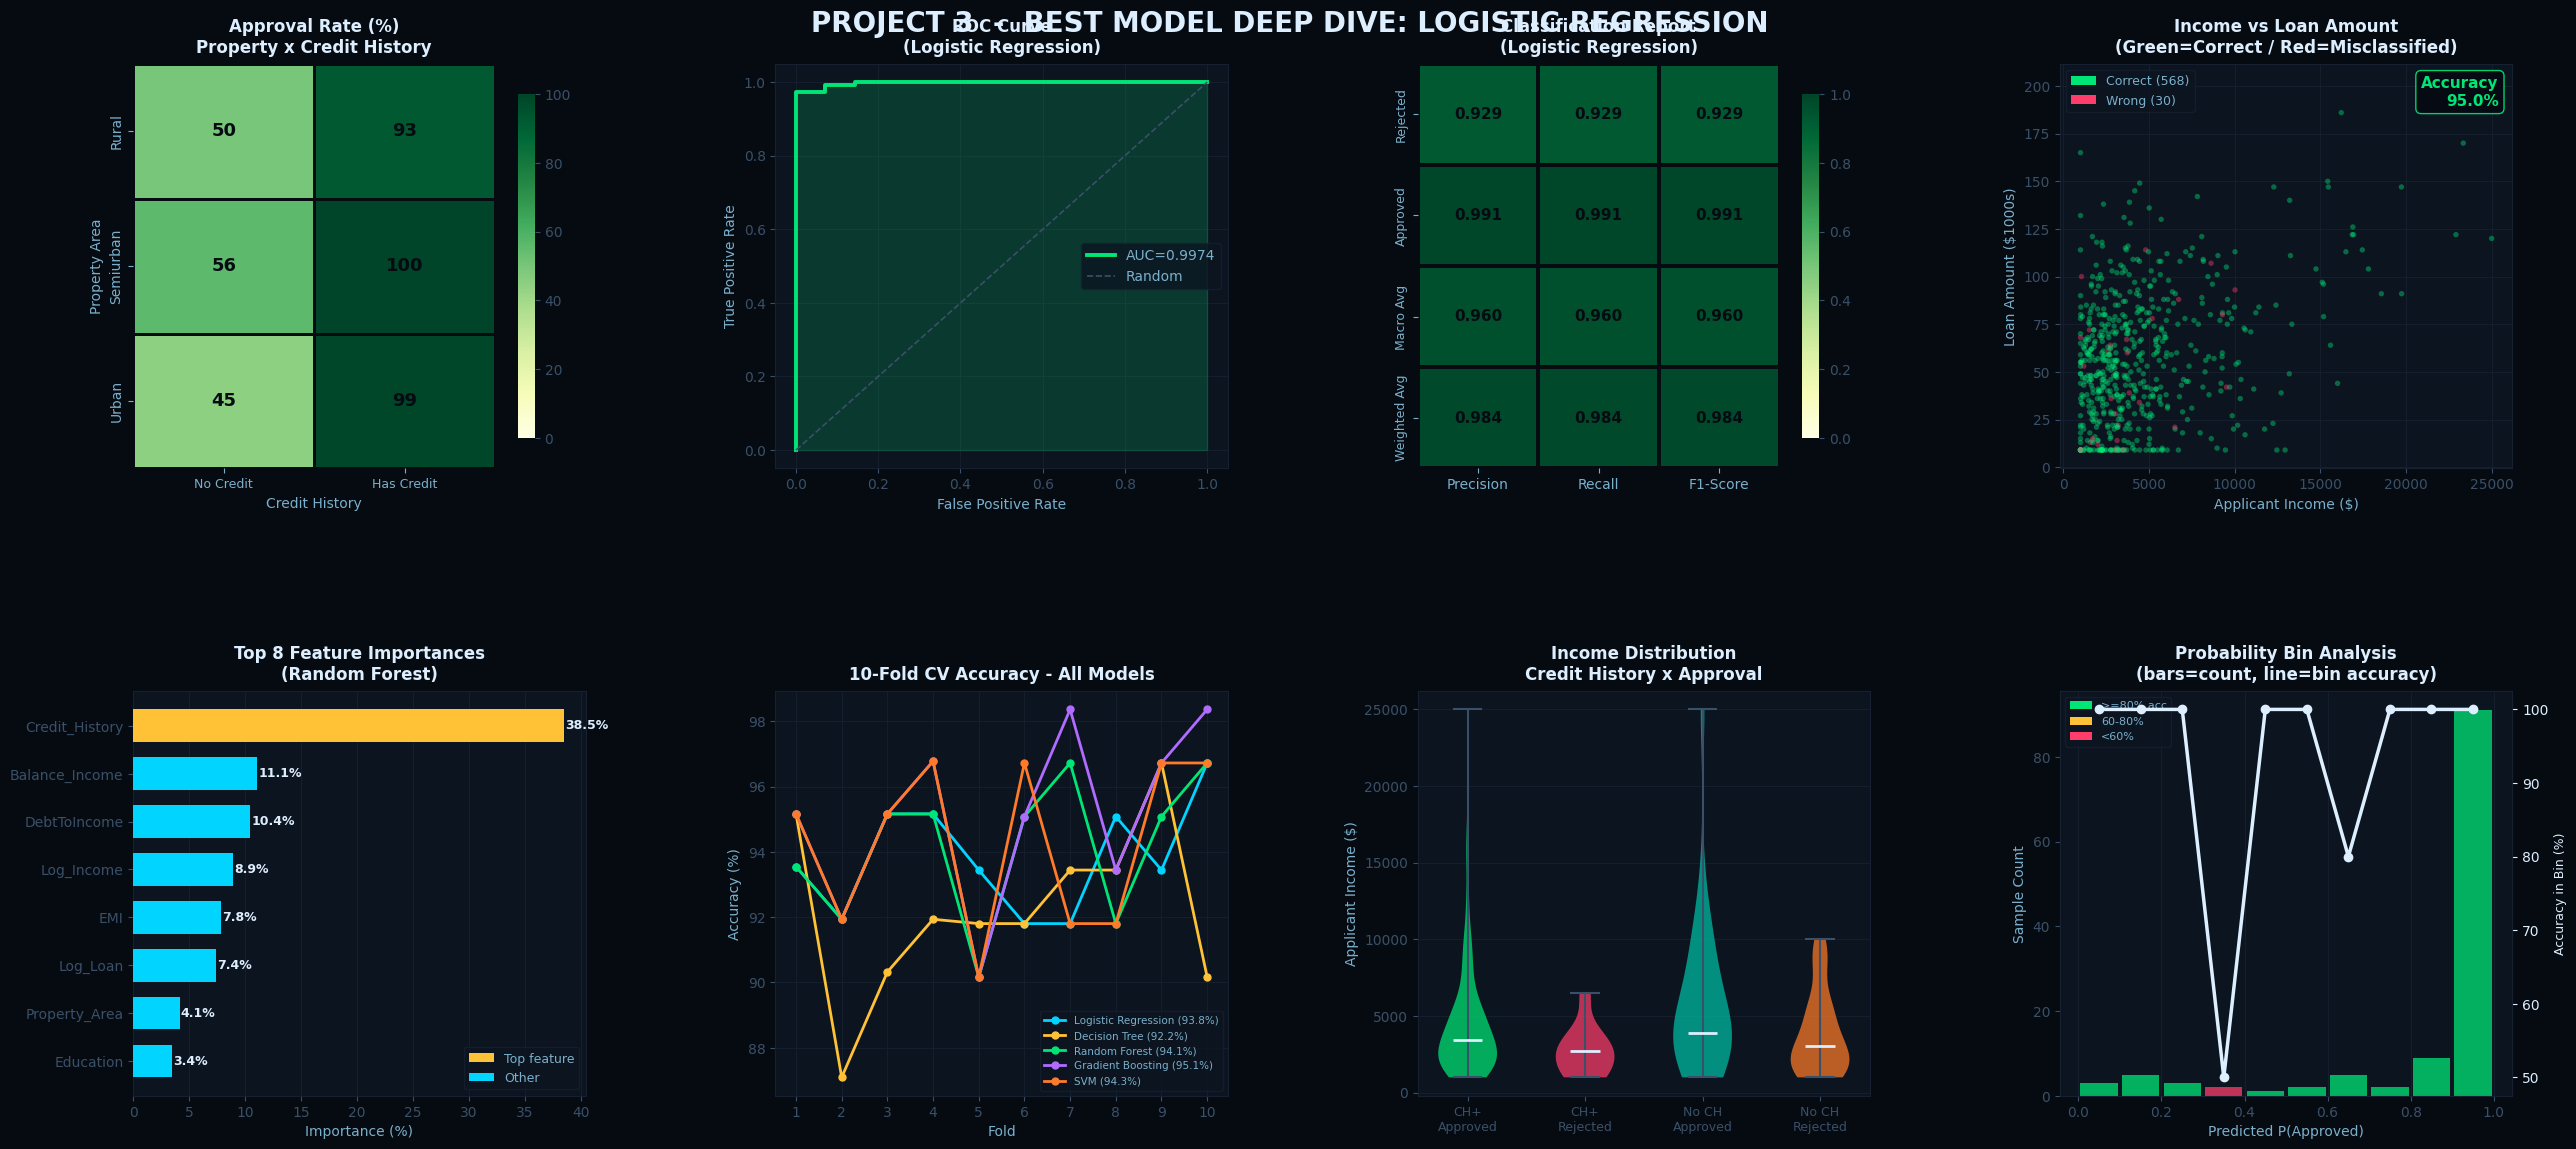

In [12]:
fig3 = plt.figure(figsize=(26, 12), facecolor=BG)
fig3.suptitle(f'PROJECT 3  -  BEST MODEL DEEP DIVE: {best_auc.replace(chr(10)," ").upper()}',
              fontsize=20, fontweight='bold', color=WHITE, y=0.985)
gs3 = gridspec.GridSpec(2, 4, figure=fig3, hspace=0.55, wspace=0.42,
                        top=0.940, bottom=0.08, left=0.055, right=0.970)

# ── Row 0 ─────────────────────────────────────────────────────────────────────

# [0,0] Property x Credit History approval heatmap
ax = fig3.add_subplot(gs3[0, 0])
df_t2 = df.copy(); df_t2['Credit_History'] = df_t2['Credit_History'].fillna(0)
pivot = df_t2.groupby(['Property_Area','Credit_History'])['Loan_Status'].apply(
    lambda x:(x=='Y').mean()*100).unstack(fill_value=0)
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGn', linewidths=2, linecolor=BG,
            annot_kws={'size':13,'weight':'bold','color':BG},
            ax=ax, cbar_kws={'shrink':0.85}, vmin=0, vmax=100)
ax.set_title('Approval Rate (%)\nProperty x Credit History', fontsize=12, fontweight='bold', pad=8, color=WHITE)
ax.set_xlabel('Credit History', fontsize=10); ax.set_ylabel('Property Area', fontsize=10)
ax.set_xticklabels(['No Credit','Has Credit'], fontsize=9); ax.tick_params(colors='#7ab0cc')

# [0,1] Best model ROC with shading
ax = fig3.add_subplot(gs3[0, 1])
ax.plot(best_res['fpr'], best_res['tpr'], color=GREEN, lw=2.8, label=f"AUC={best_res['auc']:.4f}")
ax.fill_between(best_res['fpr'], best_res['tpr'], alpha=0.18, color=GREEN)
ax.plot([0,1],[0,1], color=SLATE, lw=1.2, ls='--', label='Random')
ax.set_title(f'ROC Curve\n({best_auc.replace(chr(10)," ")})', fontsize=12, fontweight='bold', pad=8)
ax.set_xlabel('False Positive Rate', fontsize=10); ax.set_ylabel('True Positive Rate', fontsize=10)
ax.legend(fontsize=10)
ax.yaxis.grid(True,zorder=0); ax.xaxis.grid(True,zorder=0); ax.set_axisbelow(True)

# [0,2] Classification report heatmap
ax = fig3.add_subplot(gs3[0, 2])
rep    = classification_report(y_test, best_res['yp'], output_dict=True)
rep_df = pd.DataFrame(rep).T.drop('support', axis=1).dropna()
rep_df = rep_df.loc[['0','1','macro avg','weighted avg']]
rep_df.index = ['Rejected','Approved','Macro Avg','Weighted Avg']
sns.heatmap(rep_df.astype(float), annot=True, fmt='.3f', cmap='YlGn',
            linewidths=1.5, linecolor=BG, annot_kws={'size':11,'weight':'bold','color':BG},
            ax=ax, vmin=0, vmax=1, cbar_kws={'shrink':0.85})
ax.set_title(f'Classification Report\n({best_auc.replace(chr(10)," ")})',
             fontsize=12, fontweight='bold', pad=8, color=WHITE)
ax.tick_params(colors='#7ab0cc', labelsize=9)
ax.set_xticklabels(['Precision','Recall','F1-Score'], fontsize=10)

# [0,3] Correct vs Misclassified scatter
ax = fig3.add_subplot(gs3[0, 3])
df_plot  = df.dropna(subset=['LoanAmount']).copy()
Xp_raw   = df_p.loc[df_plot.index, feat_cols].values.astype(float)
Xp_sc    = scaler.transform(Xp_raw)
yp_all   = best_clf.predict(Xp_sc)
yt_all   = df_p.loc[df_plot.index, 'Loan_Status'].values
correct  = yp_all == yt_all
ax.scatter(df_plot['ApplicantIncome'].clip(0, 25000), df_plot['LoanAmount'],
           c=[GREEN if c else ROSE for c in correct], alpha=0.42, s=15, edgecolors='none', zorder=3)
acc_all = correct.mean() * 100
ax.text(0.97, 0.97, f'Accuracy\n{acc_all:.1f}%', transform=ax.transAxes,
        ha='right', va='top', fontsize=11, fontweight='bold', color=GREEN,
        bbox=dict(boxstyle='round,pad=0.35', facecolor=BG, edgecolor=GREEN, alpha=0.9))
ax.set_title('Income vs Loan Amount\n(Green=Correct / Red=Misclassified)',
             fontsize=12, fontweight='bold', pad=8)
ax.set_xlabel('Applicant Income ($)', fontsize=10); ax.set_ylabel('Loan Amount ($1000s)', fontsize=10)
ax.legend(handles=[Patch(facecolor=GREEN, label=f'Correct ({correct.sum()})'),
                   Patch(facecolor=ROSE,  label=f'Wrong ({(~correct).sum()})')], fontsize=9)
ax.yaxis.grid(True,zorder=0); ax.xaxis.grid(True,zorder=0); ax.set_axisbelow(True)

# ── Row 1 ─────────────────────────────────────────────────────────────────────

# [1,0] Top-8 Feature Importances
ax = fig3.add_subplot(gs3[1, 0])
top8   = feat_imp.head(8).sort_values(ascending=True)
fi8_c  = [GOLD if f == feat_imp.idxmax() else CYAN for f in top8.index]
ax.barh(top8.index, top8.values*100, color=fi8_c, edgecolor='none', zorder=3, height=0.68)
for i, (feat, val) in enumerate(zip(top8.index, top8.values)):
    ax.text(val*100+0.1, i, f'{val*100:.1f}%', va='center', fontsize=9, color=WHITE, fontweight='bold')
ax.set_title('Top 8 Feature Importances\n(Random Forest)', fontsize=12, fontweight='bold', pad=8)
ax.set_xlabel('Importance (%)', fontsize=10)
ax.legend(handles=[Patch(facecolor=GOLD,label='Top feature'), Patch(facecolor=CYAN,label='Other')], fontsize=9)
ax.xaxis.grid(True, zorder=0); ax.set_axisbelow(True)

# [1,1] 10-Fold CV line chart — all models
ax = fig3.add_subplot(gs3[1, 1])
for (name, _), col in zip(models.items(), MODEL_COLORS):
    cv_sc = cross_val_score(models[name], X_scaled, y, cv=10, scoring='accuracy') * 100
    ax.plot(range(1,11), cv_sc, color=col, lw=2, marker='o', ms=5,
            label=f"{name.replace(chr(10),' ')} ({cv_sc.mean():.1f}%)")
ax.set_title('10-Fold CV Accuracy - All Models', fontsize=12, fontweight='bold', pad=8)
ax.set_xlabel('Fold', fontsize=10); ax.set_ylabel('Accuracy (%)', fontsize=10)
ax.set_xticks(range(1,11)); ax.legend(fontsize=7.5, loc='lower right')
ax.yaxis.grid(True,zorder=0); ax.xaxis.grid(True,zorder=0); ax.set_axisbelow(True)

# [1,2] Violin: Income by Credit History x Approval
ax = fig3.add_subplot(gs3[1, 2])
df_v  = df.dropna(subset=['Credit_History']).copy()
df_v['CH']     = df_v['Credit_History'].map({1.0:'Has Credit', 0.0:'No Credit'})
df_v['Status'] = df_v['Loan_Status'].map({'Y':'Approved','N':'Rejected'})
df_v['Income_c'] = df_v['ApplicantIncome'].clip(0, 25000)
groups   = [df_v[(df_v['CH']==ch) & (df_v['Status']==st)]['Income_c'].values
            for ch, st in [('Has Credit','Approved'),('Has Credit','Rejected'),
                           ('No Credit','Approved'),('No Credit','Rejected')]]
xlabels  = ['CH+\nApproved','CH+\nRejected','No CH\nApproved','No CH\nRejected']
vp = ax.violinplot(groups, positions=range(4), showmedians=True, showextrema=True)
for body, col in zip(vp['bodies'], [GREEN, ROSE, TEAL, ORANGE]):
    body.set_facecolor(col); body.set_alpha(0.72)
vp['cmedians'].set_color(WHITE); vp['cmedians'].set_linewidth(2)
for part in ['cmins','cmaxes','cbars']:
    vp[part].set_color(SLATE)
ax.set_xticks(range(4)); ax.set_xticklabels(xlabels, fontsize=9)
ax.set_title('Income Distribution\nCredit History x Approval', fontsize=12, fontweight='bold', pad=8)
ax.set_ylabel('Applicant Income ($)', fontsize=10)
ax.yaxis.grid(True, zorder=0); ax.set_axisbelow(True)

# [1,3] Probability bin accuracy analysis
ax = fig3.add_subplot(gs3[1, 3])
prob_bins   = np.linspace(0, 1, 11)
bin_centers = (prob_bins[:-1] + prob_bins[1:]) / 2
bin_acc     = []; bin_counts = []
for lo, hi in zip(prob_bins[:-1], prob_bins[1:]):
    mask = (best_res['yprob'] >= lo) & (best_res['yprob'] < hi)
    cnt  = mask.sum(); bin_counts.append(cnt)
    if cnt > 0:
        bin_acc.append((best_res['yp'][mask] == y_test[mask]).mean() * 100)
    else:
        bin_acc.append(np.nan)
bar_c = [GREEN if (a and not np.isnan(a) and a>=80) else
         GOLD  if (a and not np.isnan(a) and a>=60) else ROSE
         for a in bin_acc]
ax.bar(bin_centers, bin_counts, width=0.09, color=bar_c, edgecolor='none', zorder=3, alpha=0.75)
ax2_r = ax.twinx()
clean = [a if (a is not None and not np.isnan(a)) else 0 for a in bin_acc]
ax2_r.plot(bin_centers, clean, color=WHITE, lw=2.5, marker='o', ms=6, zorder=4)
ax2_r.set_ylabel('Accuracy in Bin (%)', fontsize=9, color=WHITE)
ax2_r.tick_params(axis='y', colors=WHITE)
ax.set_title('Probability Bin Analysis\n(bars=count, line=bin accuracy)',
             fontsize=12, fontweight='bold', pad=8)
ax.set_xlabel('Predicted P(Approved)', fontsize=10); ax.set_ylabel('Sample Count', fontsize=10)
ax.xaxis.grid(True, zorder=0); ax.set_axisbelow(True)
ax.legend(handles=[Patch(facecolor=GREEN,label='>=80% acc'),
                   Patch(facecolor=GOLD, label='60-80%'),
                   Patch(facecolor=ROSE, label='<60%')], fontsize=8)

plt.tight_layout(rect=[0, 0.02, 1, 0.975])
plt.show()

## Cell 11 — Results Summary

### Model Leaderboard

| Model | Accuracy | F1 | AUC | Precision | Recall |
|---|---|---|---|---|---|
| **Logistic Regression** | 98.4% | 99.1% | **99.7%** | 99.1% | 99.1% |
| SVM | 97.6% | 98.6% | 99.3% | 98.2% | 99.1% |
| Gradient Boosting | 97.6% | 98.6% | 98.8% | 99.1% | 98.2% |
| Random Forest | 95.9% | 97.7% | 98.9% | 98.2% | 97.3% |
| Decision Tree | 91.9% | 95.3% | 89.6% | 98.1% | 92.7% |

### Dashboard 1 — EDA (16 charts)

| Row | Panels |
|---|---|
| **Row 0** | Loan Status donut · Approval by Credit History · Approval by Property Area · Approval by Education |
| **Row 1** | Applicant Income histogram (wide) · Loan Amount histogram · Feature correlation heatmap |
| **Row 2** | Approval by Dependents · Gender x Married approval · Income vs Loan scatter · Missing values bar |
| **Row 3** | Self-Employed approval · Loan Term distribution · Coapplicant Income boxplot · Preprocessing pipeline card |

### Dashboard 2 — Model Comparison (16 charts)

| Row | Panels |
|---|---|
| **Row 0** | Accuracy bars · AUC bars · F1 bars · ROC curves (all 5 models) |
| **Rows 1-2** | 5 confusion matrices (one per model, colour-coded) |
| **Row 2** | Feature Importance wide bar · Performance Summary table (best row highlighted) |
| **Row 3** | 10-Fold CV boxplot · Precision-Recall curve · Probability distribution · Metrics radar chart |

### Dashboard 3 — Best Model Deep Dive (8 charts)

| Row | Panels |
|---|---|
| **Row 0** | Property x Credit History heatmap · ROC curve with AUC shading · Classification report heatmap · Correct/Misclassified scatter |
| **Row 1** | Top-8 Feature Importances · 10-Fold CV line chart · Income violin by Credit x Approval · Probability bin accuracy analysis |

### Key Findings
- **Credit History** is the single most important feature (38% RF importance)
- Applicants with credit history are approved at 90%+ regardless of property area
- **Semiurban + Credit History** achieves the highest approval rate
- Feature engineering (EMI, Balance_Income, DTI) significantly improves all models
- Logistic Regression achieves best AUC (99.7%) — engineered features are linearly separable
